# Analiza podatkov

V tem zvezku vizualno raziščemo očiščeni dataset (porazdelitve, manjkajoče vrednosti, vpliv rankinga in površine).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Nalaganje podatkov

In [2]:
df = pd.read_csv("./data/processed/matches_clean.csv")

df["tourney_date"] = pd.to_datetime(df["tourney_date"])
df["year"] = df["tourney_date"].dt.year

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

### Število tekem po letih

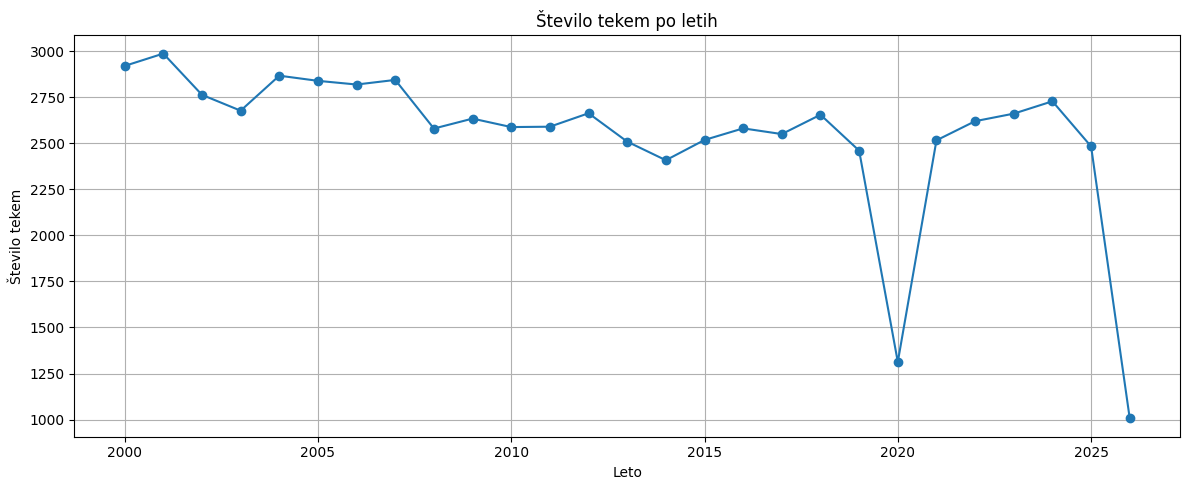

In [3]:
matches_per_year = df.groupby("year").size()

plt.figure(figsize=(12, 5))
plt.plot(matches_per_year.index, matches_per_year.values, marker="o")
plt.title("Število tekem po letih")
plt.xlabel("Leto")
plt.ylabel("Število tekem")
plt.tight_layout()
plt.show()

### Število tekem po igralni površini

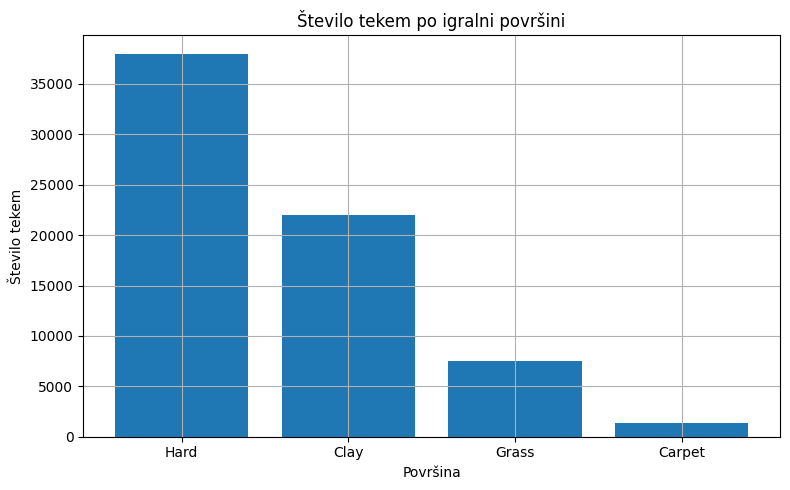

In [4]:
surface_counts = df["surface"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(surface_counts.index, surface_counts.values)
plt.title("Število tekem po igralni površini")
plt.xlabel("Površina")
plt.ylabel("Število tekem")
plt.tight_layout()
plt.show()

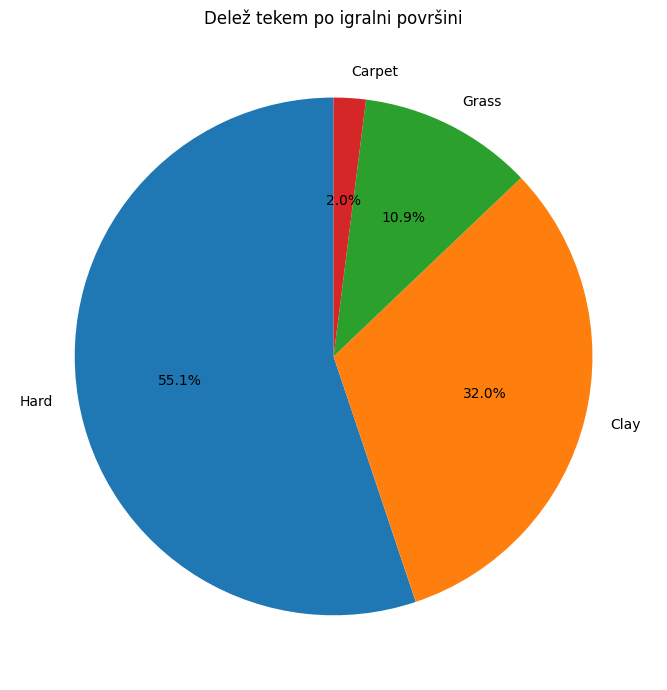

In [5]:
surface_share = df["surface"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 7))

plt.pie(
    surface_share.values,
    labels=surface_share.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Delež tekem po igralni površini")
plt.tight_layout()
plt.show()

Tortni graf prikazuje delež tekem po posamezni površini.

### Število tekem po nivoju turnirja

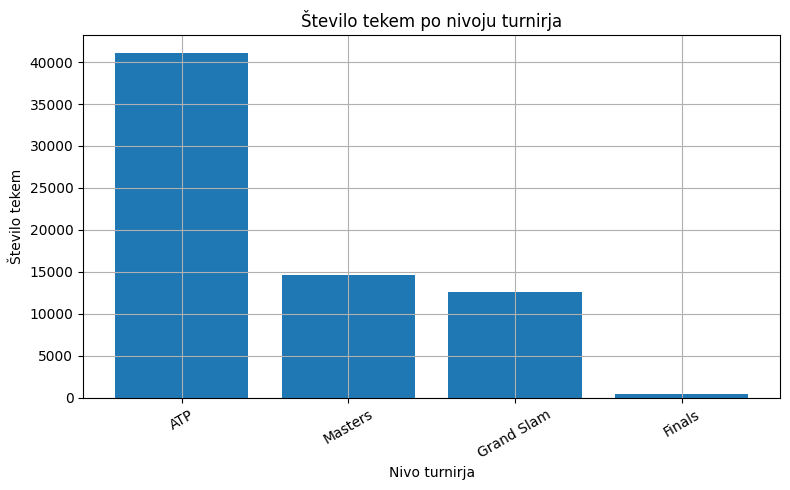

In [6]:
level_names = {
    "G": "Grand Slam",
    "M": "Masters",
    "A": "ATP",
    "F": "Finals",
    "D": "Davis Cup"
}

df["tourney_level_name"] = df["tourney_level"].map(level_names).fillna(df["tourney_level"])

level_counts = df["tourney_level_name"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(level_counts.index, level_counts.values)
plt.title("Število tekem po nivoju turnirja")
plt.xlabel("Nivo turnirja")
plt.ylabel("Število tekem")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Manjkajoče vrednosti po stolpcih

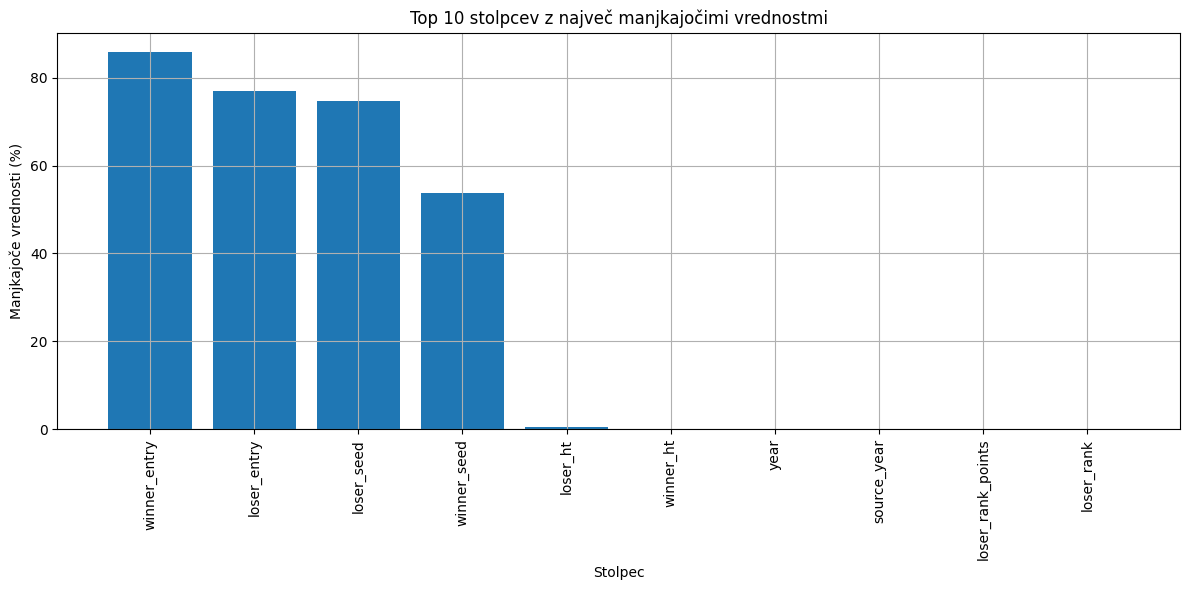

In [7]:
missing = df.isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
plt.bar(missing.index[:10], missing.values[:10])
plt.title("Top 10 stolpcev z največ manjkajočimi vrednostmi")
plt.xlabel("Stolpec")
plt.ylabel("Manjkajoče vrednosti (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Porazdelitev rankingov

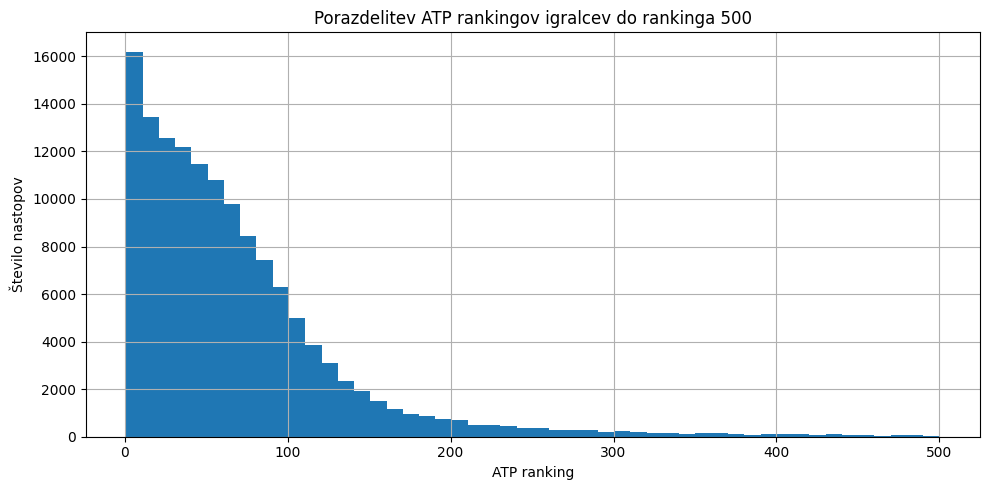

In [8]:
rankings = pd.concat([
    df["winner_rank"],
    df["loser_rank"]
], ignore_index=True).dropna()

rankings_top500 = rankings[rankings <= 500]

plt.figure(figsize=(10, 5))
plt.hist(rankings_top500, bins=50)
plt.title("Porazdelitev ATP rankingov igralcev do rankinga 500")
plt.xlabel("ATP ranking")
plt.ylabel("Število nastopov")
plt.tight_layout()
plt.show()

### Delež zmag boljšega rankinga

Preverimo, kako pogosto zmaga bolje rangirani igralec. Vrednost izrazito nad 50 % pomeni, da je ranking smiseln napovedni signal.

In [9]:
rank_df = df.dropna(subset=["winner_rank", "loser_rank"]).copy()

rank_df["better_ranked_won"] = rank_df["winner_rank"] < rank_df["loser_rank"]

better_ranked_winrate = rank_df["better_ranked_won"].mean() * 100

print(f"Boljše rangirani igralec je zmagal v {better_ranked_winrate:.2f}% tekem.")

Boljše rangirani igralec je zmagal v 65.33% tekem.


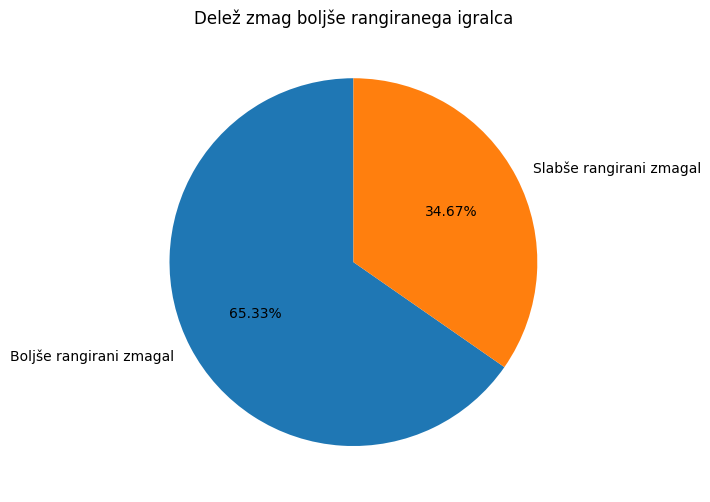

In [10]:
shares = rank_df["better_ranked_won"].value_counts(normalize=True) * 100
shares.index = [
    "Boljše rangirani zmagal" if x else "Slabše rangirani zmagal"
    for x in shares.index
]

plt.figure(figsize=(7, 7))
plt.pie(
    shares.values,
    labels=shares.index,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Delež zmag boljše rangiranega igralca")
plt.tight_layout()
plt.show()

### Delež zmag favorita po površinah

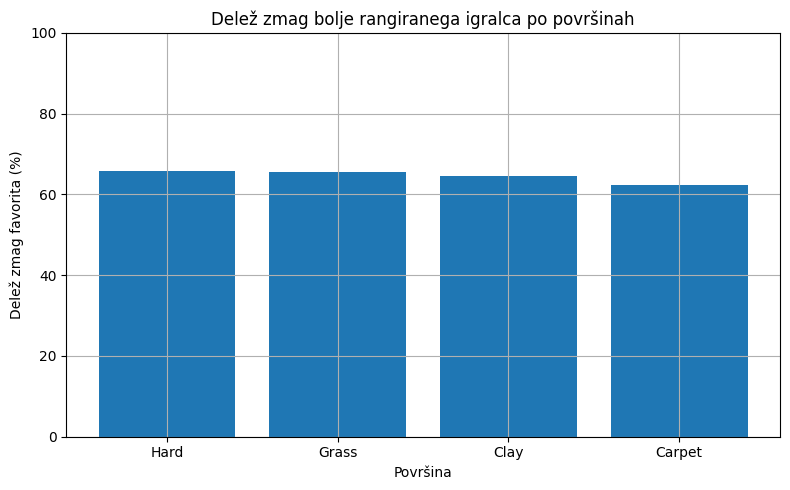

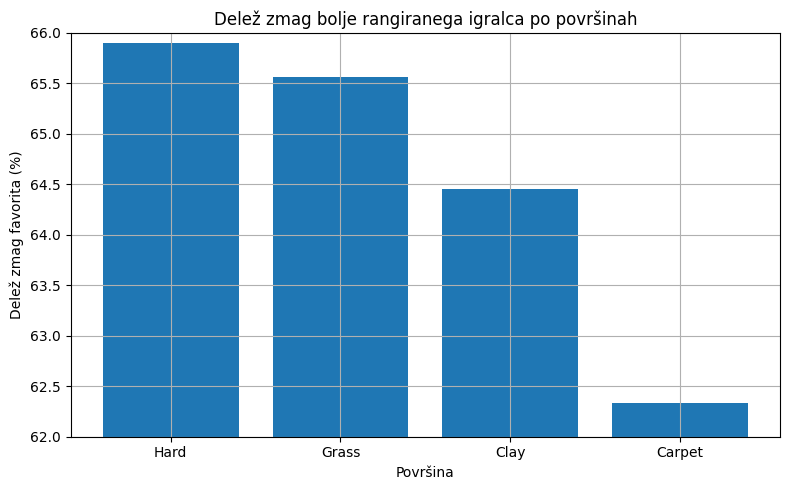

In [11]:
surface_rank_df = df.dropna(subset=["winner_rank", "loser_rank", "surface"]).copy()

surface_rank_df["better_ranked_won"] = (
    surface_rank_df["winner_rank"] < surface_rank_df["loser_rank"]
)

surface_favorite_winrate = (
    surface_rank_df
    .groupby("surface")["better_ranked_won"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8, 5))
plt.bar(surface_favorite_winrate.index, surface_favorite_winrate.values)
plt.title("Delež zmag bolje rangiranega igralca po površinah")
plt.xlabel("Površina")
plt.ylabel("Delež zmag favorita (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(surface_favorite_winrate.index, surface_favorite_winrate.values)
plt.title("Delež zmag bolje rangiranega igralca po površinah")
plt.xlabel("Površina")
plt.ylabel("Delež zmag favorita (%)")
plt.ylim(62, 66)
plt.tight_layout()
plt.show()

Drugi graf je zoomirana verzija prvega, da so razlike med površinami bolj vidne.

In [12]:
surface_summary = (
    surface_rank_df
    .groupby("surface")
    .agg(
        matches=("better_ranked_won", "size"),
        favorite_winrate=("better_ranked_won", "mean")
    )
)

surface_summary["favorite_winrate"] *= 100
surface_summary = surface_summary.sort_values("favorite_winrate", ascending=False)

surface_summary

,matches,favorite_winrate
surface,,
Hard,37925,65.895847
Grass,7485,65.557782
Clay,21991,64.458187
Carpet,1378,62.336720


### Starost igralcev skozi leta

In [13]:
winner_ages = df[["year", "winner_age"]].rename(columns={"winner_age": "age"})
loser_ages = df[["year", "loser_age"]].rename(columns={"loser_age": "age"})

ages = pd.concat([winner_ages, loser_ages], ignore_index=True).dropna()

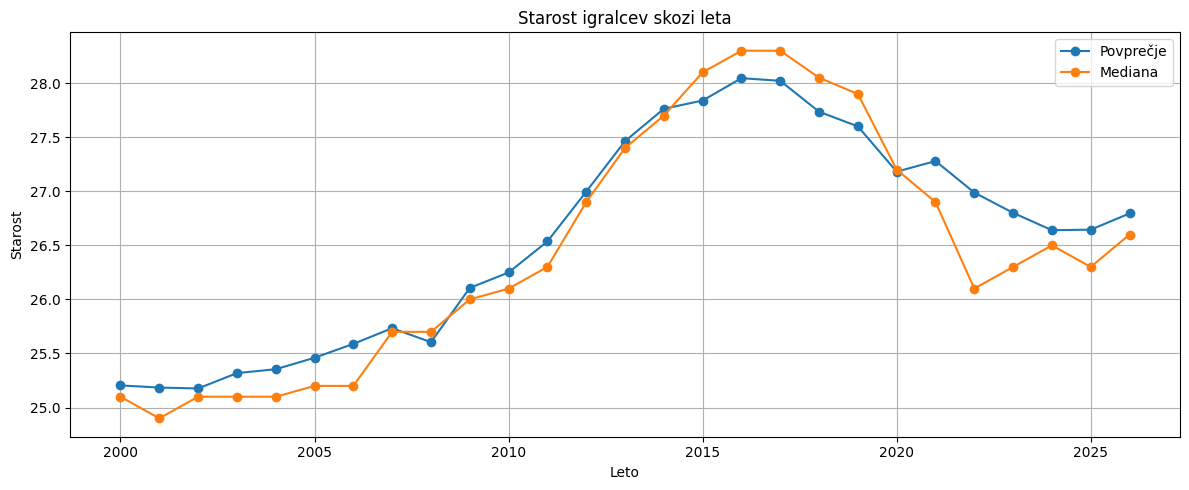

In [14]:
age_by_year = ages.groupby("year")["age"].agg(["mean", "median"])

plt.figure(figsize=(12, 5))
plt.plot(age_by_year.index, age_by_year["mean"], marker="o", label="Povprečje")
plt.plot(age_by_year.index, age_by_year["median"], marker="o", label="Mediana")
plt.title("Starost igralcev skozi leta")
plt.xlabel("Leto")
plt.ylabel("Starost")
plt.legend()
plt.tight_layout()
plt.show()

### Ranking razlika in verjetnost zmage favorita

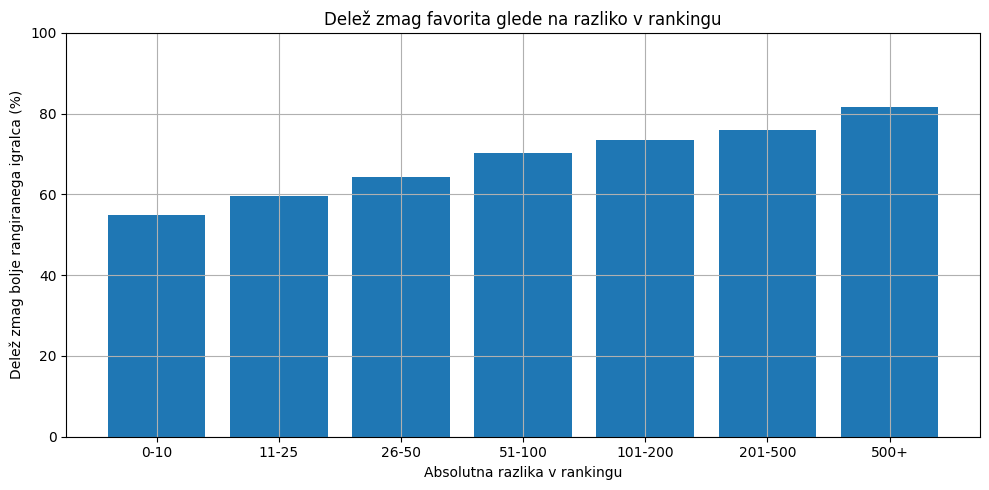

In [15]:
rank_diff_df = df.dropna(subset=["winner_rank", "loser_rank"]).copy()

rank_diff_df["rank_diff_abs"] = abs(rank_diff_df["winner_rank"] - rank_diff_df["loser_rank"])
rank_diff_df["better_ranked_won"] = rank_diff_df["winner_rank"] < rank_diff_df["loser_rank"]

bins = [0, 10, 25, 50, 100, 200, 500, np.inf]
labels = ["0-10", "11-25", "26-50", "51-100", "101-200", "201-500", "500+"]

rank_diff_df["rank_diff_group"] = pd.cut(
    rank_diff_df["rank_diff_abs"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

rank_group_winrate = (
    rank_diff_df
    .groupby("rank_diff_group", observed=True)["better_ranked_won"]
    .mean() * 100
)

plt.figure(figsize=(10, 5))
plt.bar(rank_group_winrate.index.astype(str), rank_group_winrate.values)
plt.title("Delež zmag favorita glede na razliko v rankingu")
plt.xlabel("Absolutna razlika v rankingu")
plt.ylabel("Delež zmag bolje rangiranega igralca (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()